In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
%cd /blue/chunmei.wang/hudsonshields/GraphFEX

controller_epochs = 5
cands_per_epoch = 10

small_num_nodes = [20, 50, 500]
order_of_mag_nodes = [10, 100, 1000, 10000]

node_counts = sorted(set(small_num_nodes + order_of_mag_nodes))

# so only benchmark all four methods through 10^3.
full_node_counts = [n for n in node_counts if n <= 1000]

pct_edges = 0.1

parallel_workers = 2

[Errno 2] No such file or directory: '/blue/chunmei.wang/hudsonshields/GraphFEX'
/home/hudson/GraphFEX


In [3]:
%cd ~/GraphFEX
timing_results = {}

for n in node_counts:
    degree = max(1, int(pct_edges * n))
    desired_batches = max(1, int(0.1 * degree))

    t1 = %timeit -o -r5 -n1 !python -m NumericalExperiments.HR.scripts.eval_controller_dim_x \
        --num_workers 1 \
        --num_epochs 60 \
        --controller_epochs {controller_epochs} \
        --nodes {n} \
        --num_cands_per_epoch {cands_per_epoch} \
        --num_stoch_batches {desired_batches} \
        --pct_edges {pct_edges}

    timing_results[n] = {
        "mean": t1.average / controller_epochs / cands_per_epoch,
        "std": t1.stdev / controller_epochs / cands_per_epoch,
    }
print(timing_results)

/home/hudson/GraphFEX
Using device: cuda
Using 1 parallel processes for candidate evaluation.
Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 3 on GPU 0
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.13 seconds
Epoch 0 pmfs: [array([[0.36028597, 0.31176743, 0.3279466 ]], dtype=float32), array([[0.3609234 , 0.31554487, 0.32353166]], dtype=float32), array([[0.33160508, 0.3941712 , 0.27422372]], dtype=float32), array([[0.13404845, 0.13406453, 0.15932645, 0.14537433, 0.14734879,
        0.14364427, 0.13619316]], dtype=float32), array([[0.16155946, 0.1478529 , 0.12678409, 0.14467181, 0.14257222,
        0.14054994, 0.13600954]], dtype=float32), array([[0.14682388, 0.14479068, 0.14612658, 0.15361485, 0.14775665,
        0.13123745

In [ ]:
par_stoch_timing_results = {}

for n in node_counts:
    degree = max(1, int(pct_edges * n))
    desired_batches = max(1, int(0.1 * degree))

    t1 = %timeit -o -r5 -n1 !python -m NumericalExperiments.HR.scripts.eval_controller_dim_x \
        --num_workers {parallel_workers} \
        --num_epochs 60 \
        --controller_epochs {controller_epochs} \
        --nodes {n} \
        --num_cands_per_epoch {cands_per_epoch} \
        --num_stoch_batches {desired_batches} \
        --pct_edges {pct_edges}

    par_stoch_timing_results[n] = {
        "mean": t1.average / controller_epochs / cands_per_epoch,
        "std": t1.stdev / controller_epochs / cands_per_epoch,
    }
print(par_stoch_timing_results)
%cd /blue/chunmei.wang/hudsonshields/GraphFEX

Using device: cuda
Using 2 parallel processes for candidate evaluation.
Using device: cuda
Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 3 on GPU 0
Evaluating candidate 4 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.09 seconds
Epoch 0 pmfs: [array([[0.36028597, 0.31176743, 0.3279466 ]], dtype=float32), array([[0.3609234 , 0.31554487, 0.32353166]], dtype=float32), array([[0.33160508, 0.3941712 , 0.27422372]], dtype=float32), array([[0.13404845, 0.13406453, 0.15932645, 0.14537433, 0.14734879,
        0.14364427, 0.13619316]], dtype=float32), array([[0.16155946, 0.1478529 , 0.12678409, 0.14467181, 0.14257222,
        0.14054994, 0.13600954]], dtype=float32), array([[0.14682388, 0.14479068, 0.14612658, 0.15361485, 0.14775665,
        0.13123745, 0

In [8]:
import matplotlib.pyplot as plt
import numpy as np

experiment_labels = [
    "Serial",
    "Stochastic",
    "Parallel",
    "Parallel+Stochastic"
]

experiments = [
    #control_timing_results,
    timing_results,
    #parallel_timing_results,
    par_stoch_timing_results
]

colors = {
    "Serial": "black",
    "Stochastic": "orange",
    "Parallel": "blue",
    "Parallel+Stochastic": "green",
}

styles = {
    "Serial": {
        "marker": "o",
        "linestyle": "-"
    },
    "Stochastic": {
        "marker": "s",
        "linestyle": "-"
    },
    "Parallel": {
        "marker": "^",
        "linestyle": "--"
    },
    "Parallel+Stochastic": {
        "marker": "D",
        "linestyle": "--"
    },
}
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",

    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

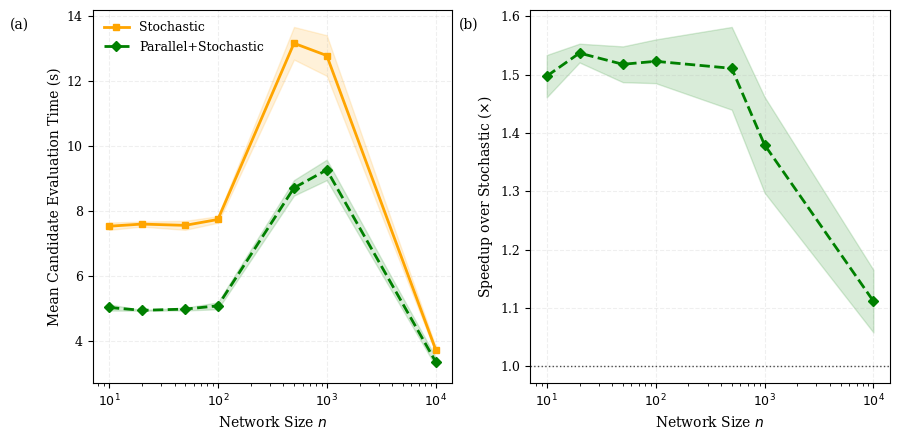

In [11]:
# Large-network scalability:
# Stochastic vs Parallel + Stochastic through N = 10^4

fig, (ax_main, ax_speedup) = plt.subplots(1, 2, figsize=(9, 4.5), sharex=True)
large_scale_experiments = [
    ("Stochastic", timing_results),
    ("Parallel+Stochastic", par_stoch_timing_results),
]

scalable_nodes = node_counts[:]


# (a) Runtime scaling
for label, exp in large_scale_experiments:

    means = np.array([exp[n]["mean"] for n in scalable_nodes])
    stds = np.array([exp[n]["std"] for n in scalable_nodes])

    ax_main.plot(
        scalable_nodes,
        means,
        label=label,
        color=colors[label],
        marker=styles[label]["marker"],
        linestyle=styles[label]["linestyle"],
        linewidth=2,
        markersize=5,
    )

    ax_main.fill_between(
        scalable_nodes,
        means - stds,
        means + stds,
        color=colors[label],
        alpha=0.15,
    )
ax_main.set_xscale("log")
figure2_ticks = [10, 100, 1000, 10000]

ax_main.set_xticks(figure2_ticks)
ax_main.set_xticklabels([rf"$10^{{{int(np.log10(n))}}}$" for n in figure2_ticks])
ax_main.set_xlabel(r"Network Size $n$")
ax_main.set_ylabel("Mean Candidate Evaluation Time (s)")

ax_main.legend(fontsize=9, frameon=False)
ax_main.grid(alpha=0.2,linestyle="--")
ax_main.text(-0.23, 0.98, r"(a)", transform=ax_main.transAxes, va="top")


# (b) Speedup of Parallel+Stochastic over Stochastic
stochastic_means = np.array([timing_results[n]["mean"] for n in scalable_nodes])
stochastic_stds = np.array([timing_results[n]["std"] for n in scalable_nodes])

parallel_stoch_means = np.array([par_stoch_timing_results[n]["mean"] for n in scalable_nodes])
parallel_stoch_stds = np.array([par_stoch_timing_results[n]["std"] for n in scalable_nodes])

speedup = stochastic_means / parallel_stoch_means
speedup_std = speedup * np.sqrt((stochastic_stds / stochastic_means) ** 2 + (parallel_stoch_stds / parallel_stoch_means) ** 2)

ax_speedup.plot(
    scalable_nodes,
    speedup,
    label="Parallel+Stochastic",
    color=colors["Parallel+Stochastic"],
    marker=styles["Parallel+Stochastic"]["marker"],
    linestyle=styles["Parallel+Stochastic"]["linestyle"],
    linewidth=2,
    markersize=5,
)

ax_speedup.fill_between(
    scalable_nodes,
    speedup - speedup_std,
    speedup + speedup_std,
    color=colors["Parallel+Stochastic"],
    alpha=0.15,
)


# 1x = no improvement over stochastic batching
ax_speedup.axhline(
    1,
    color="black",
    linewidth=1,
    linestyle=":",
    alpha=0.7
)

ax_speedup.set_xscale("log")
ax_speedup.set_xticks(figure2_ticks)
ax_speedup.set_xticklabels([rf"$10^{{{int(np.log10(n))}}}$" for n in figure2_ticks])
ax_speedup.set_xlabel(r"Network Size $n$")
ax_speedup.set_ylabel(r"Speedup over Stochastic ($\times$)")

ax_speedup.grid(alpha=0.2, linestyle="--")
ax_speedup.text(-0.2, 0.98, r"(b)", transform=ax_speedup.transAxes, va="top")

plt.tight_layout()
plt.show()

In [ ]:
oops

In [ ]:
import os

# 1. Move Jupyter's working directory into the script folder
%cd ~/GraphFEX/HR/scripts
%cd ~/blue/chunmei.wang/hudsonshields/GraphFEX/HR/scripts


mean_times = []
std_dev_times = []

controller_epochs = 5
for num_workers in range(1, 11):
    # 2. Run the script directly without the folder prefix
    t1 = %timeit -o -r5 -n1 !python HR/scripts/eval_controller_dim_x.py --num_workers {num_workers} --num_epochs 80 --controller_epochs {controller_epochs}

    # scale by number of controller epochs because each timing run includes multiple controller epochs, and i want to find the per epoch time
    mean_times.append(t1.average / controller_epochs)
    std_dev_times.append(t1.stdev / controller_epochs)

# 3. Optional: Move back to your project root when finished
%cd ~/GraphFEX
%cd ~/blue/chunmei.wang/hudsonshields/GraphFEX
plt.errorbar(range(1, 11), mean_times, yerr=std_dev_times)
plt.xlabel(r"Number of Parallel Processes")
plt.ylabel(r"Clock Time (s)")
plt.title(r"Multiprocessor Scaling for 10 Cands (64bs 80ep)")
plt.show()